Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality.

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

An XGBoost (Extreme Gradient Boosting) model is also trained and evaluated for a comparison. However, the MLP is expected to perform better as MLPs typically perform better with complex feature learning whilst EGBoost is better with structured data, and its performance depends heavily on the dataset.

These models both use 2 classes of water quality as targets. The poor/moderate classes are combined (0), whilst the good class remains seperate (2).

In [13]:
#Imports

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os

#scikit-learn
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

#For the model
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import shap

In [14]:
#Loading the csv

#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
merged_df = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")


In [15]:
#Displaying the merged df
merged_df

,downloaded_utc,layer_title,layer_id,feature_object_id,feature_global_id,geometry_x,geometry_y,attachment_id,attachment_global_id,attachment_name,...,feedback_score,County,RBD_NAME,MNCAT_NAME,Nitrate (mg/L) MID,Phosphate (mg/L) MID,Photo URL,x,y,image_path
0,2025-11-26T17:48:11Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,12,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,-4.011572,52.434782,6,120e143f-b55e-4c10-aced-8b8f36ab4561,photo-20240525-180858.jpg,...,1,Dyfed,Western Wales,Teifi and North Ceredigion,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-4.011572,52.434782,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
1,2025-11-26T17:48:17Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,13,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,-1.997459,53.932339,7,01b85181-5e16-4bce-8ec1-864890e0eee6,photo-20240526-115416.jpg,...,2,North Yorkshire,Humber,Aire and Calder,1.50,0.075,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.997459,53.932339,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
2,2025-11-26T17:48:23Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,15,9ab3ef19-b92e-495d-8330-e5cab4f52139,-0.490153,51.398517,8,93b0b358-2840-496f-9c50-beb08e550091,photo-20240531-072047.jpg,...,3,Surrey,Thames,Maidenhead and Sunbury,7.50,0.150,https://services3.arcgis.com/SQtySBftABENTpkx/...,-0.490153,51.398517,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
3,2025-11-26T17:48:29Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,16,7065d44e-868d-41a8-bc29-3e380d44a284,-1.705773,53.341469,9,967fdeb6-6016-43ed-954a-e2778dd0fe31,photo-20240531-184342.jpg,...,1,Derbyshire,Humber,Derwent Derbyshire,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.705773,53.341469,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
4,2025-11-26T17:48:35Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,17,ece94aea-b3a2-4c72-a1b0-66b329185eb8,-1.633728,53.797123,10,e895f878-0577-40ae-9a49-ecd991ffcf85,photo-20240601-110123.jpg,...,3,West Yorkshire,Humber,Aire and Calder,3.50,0.035,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.633728,53.797123,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8999,2025-11-27T14:03:26Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11545,7479327a-dda2-4647-8e19-176fc7b7c208,-1.776789,53.921762,9974,a538e4f9-dda1-437e-8f73-952f969aa748,IMG_20251108_151702379_HDR.jpg,...,3,West Yorkshire,Humber,Wharfe and Ouse Lower,10.00,1.000,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.776789,53.921762,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9000,2025-11-27T14:03:36Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11546,9ca17c49-6a38-405f-8369-caebcbb4c445,-1.682858,53.910390,9975,d6c0b93c-614f-40f8-8129-362d9b85f4b7,IMG_20251112_123816085_HDR.jpg,...,1,West Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.682858,53.910390,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9001,2025-11-27T14:03:47Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11547,f077fd29-55c0-484c-8b03-aa1d54844b54,-1.659827,53.913112,9976,1869abcf-7f8f-4a66-86ea-c1a2b0faaef3,IMG_20251112_130858731_HDR.jpg,...,1,North Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.659827,53.913112,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9002,2025-11-27T14:03:57Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11548,8279d341-cfc1-4852-8b19-a58dc6eee304,-1.625267,53.904750,9977,4af7180e-6b14-4fce-8190-948063dbb8d2,IMG_20251122_091305231_HDR.jpg,...,2,North Yorkshire,Humber,Wharfe and Ouse Lower,1.50,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.625267,53.904750,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...


In [16]:
#Select only the columns we want
#Not selecting any empty columns
filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]
filtered_df
#feedback score - 1-poor, 3-good -changes to 0...2

,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8999,7479327a-dda2-4647-8e19-176fc7b7c208,3,River,Grassland_shrub,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9000,9ca17c49-6a38-405f-8369-caebcbb4c445,1,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,Foam,Brown,NaN
9001,f077fd29-55c0-484c-8b03-aa1d54844b54,1,River,Arable_agricultural,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9002,8279d341-cfc1-4852-8b19-a58dc6eee304,2,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,NaN,Colourless,NaN


In [17]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. 

#Splitting the columns into different data types
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types (do this first)
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Can now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalisation
filtered_df.loc[:, multilabel_col] = filtered_df[multilabel_col].apply(normalize_multilabel)

# build bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(filtered_df[multilabel_col])
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

# Ensure nominal columns are strings (no lists)
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Column names
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
    base_cols = list(numeric_cols) + list(cat_names)
except Exception:
    base_cols = [f"base_{i}" for i in range(X_base_arr.shape[1])]

X_base_df = pd.DataFrame(X_base_arr, index=filtered_df.index, columns=base_cols[:X_base_arr.shape[1]])
bank_veg_df = bank_veg_df.reindex(filtered_df.index).fillna(0).astype(int)
X_df = pd.concat([X_base_df, bank_veg_df], axis=1)
X = X_df.values

y = filtered_df[TARGET].astype(int).values - 1  
#Collapse to binary classes: 1 = good, 0 = not-good (poor + moderate)
y_bin = (y == 2).astype(int)

print("Original class counts:", np.bincount(y))
print("Collapsed class counts:", np.bincount(y_bin))

print("Final X shape:", X.shape)
print("Final y shape:", y_bin.shape)

bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Original class counts: [3259 1872 3873]
Collapsed class counts: [5131 3873]
Final X shape: (9004, 64)
Final y shape: (9004,)


In [18]:
#Checking shapes of X, y, and classes
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y_bin.shape)   # (n_samples,)
print("y classes:", np.unique(y_bin))

X shape: (9004, 64)
y shape: (9004,)
y classes: [0 1]


In [19]:
#Divide the data into training, validation and testing. 

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_bin, test_size=0.10, random_state=42, stratify=y_bin)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


In [20]:
def show_class_distribution(y, name):
    counts = np.bincount(y)
    total = len(y)
    print(f"\n{name} set:")
    for cls, cnt in enumerate(counts):
        pct = 100 * cnt / total
        label = "poor" if cls == 0 else "moderate+good"
        print(f"  {label:<15}: {cnt:4d} ({pct:5.1f}%)")

show_class_distribution(y_train, "Training")
show_class_distribution(y_val, "Validation")
show_class_distribution(y_test, "Test")


Training set:
  poor           : 4105 ( 57.0%)
  moderate+good  : 3097 ( 43.0%)

Validation set:
  poor           :  513 ( 56.9%)
  moderate+good  :  388 ( 43.1%)

Test set:
  poor           :  513 ( 56.9%)
  moderate+good  :  388 ( 43.1%)


In [ ]:
#MPL model
#Training

#Setting parameters and loading training data
num_classes = len(np.unique(y_bin))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

#Cap extreme weights
for k in class_weight:
    class_weight[k] = min(class_weight[k], 3.0)

model = tf.keras.Sequential([
    layers.Input(shape=(X.shape[1],)),

    layers.Dense(512, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.35),

    layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    layers.Dense(128, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.15),

    layers.Dense(num_classes, activation='softmax')
])

opt = optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5
)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

#Storing the model history
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[es,rlr]
)

#Evaluating the model on the test set
y_test_cat = to_categorical(y_test, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

#Detailed classification metrics on validation set
y_val_proba = model.predict(X_val)
y_val_pred = np.argmax(y_val_proba, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

#Compute metrics
print("\nValidation accuracy:", accuracy_score(y_val_true, y_val_pred))
print("\nClassification report (val):")
print(classification_report(y_val_true, y_val_pred, digits=4))

print("\nConfusion matrix (val):")
print(confusion_matrix(y_val_true, y_val_pred))


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5324 - loss: 0.8175 - val_accuracy: 0.4428 - val_loss: 0.7349 - learning_rate: 3.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5494 - loss: 0.7618 - val_accuracy: 0.4584 - val_loss: 0.7334 - learning_rate: 3.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5554 - loss: 0.7519 - val_accuracy: 0.5383 - val_loss: 0.7168 - learning_rate: 3.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5597 - loss: 0.7373 - val_accuracy: 0.5816 - val_loss: 0.7028 - learning_rate: 3.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5765 - loss: 0.7231 - val_accuracy: 0.5694 - val_loss: 0.7019 - learning_rate: 3.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5753 - loss: 0.7215 - val_accuracy: 0.5760 - val_loss: 0.7109 - learning_rate: 3.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 

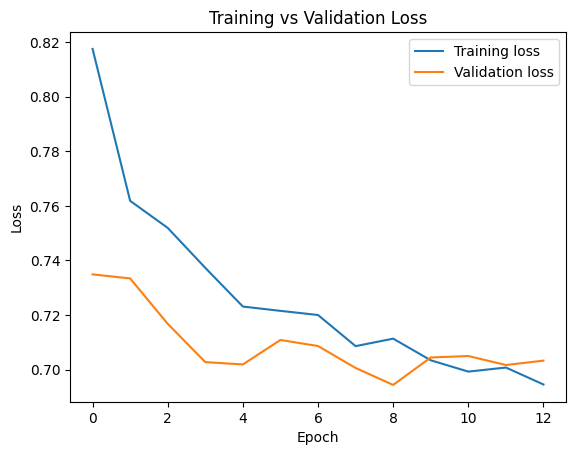

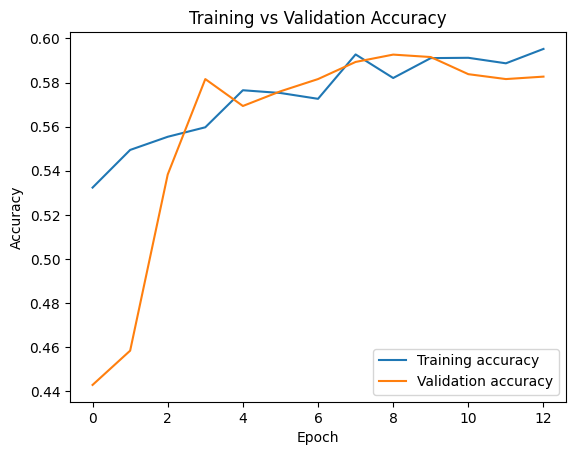

In [24]:
#Inspection-loss curves
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ACCURACY
plt.figure()
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()
